**Visualizations**

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import numpy as np
import os

In [8]:
# GitHub repository
github_url = "https://raw.githubusercontent.com/David-Nutz/Analysis-and-evaluation-of-Eniac-s-discount-strategy/main/Dataset"

In [9]:
# Load datasets from GitHub

orders_cl = pd.read_csv(f"{github_url}/orders_cl.csv")
orderlines_cl = pd.read_csv(f"{github_url}/orderlines_cl.csv")

orders_qu = pd.read_csv(f"{github_url}/orders_qu.csv")
orderlines_qu = pd.read_csv(f"{github_url}/orderlines_qu.csv")

products_qu = pd.read_csv(f"{github_url}/products_qu.csv")

Final_df = pd.read_csv(f"{github_url}/Final_df.csv")

**Discounts, ordered by price categories**

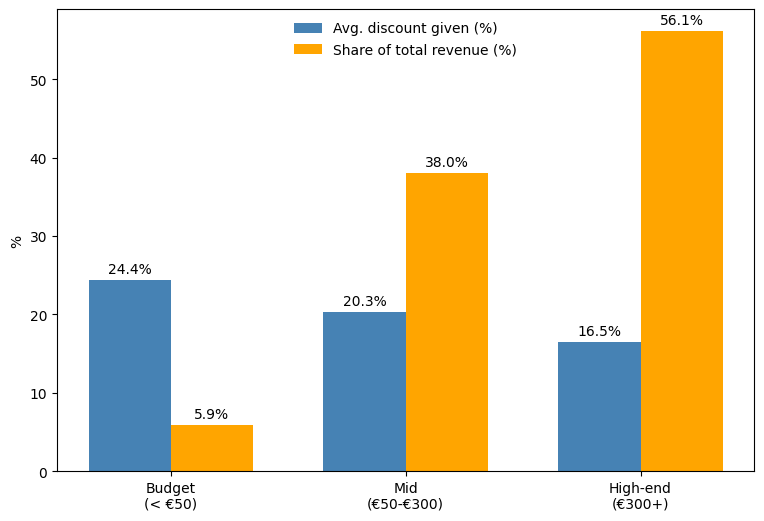

In [10]:
disc = orderlines_qu.merge(products_qu[['sku', 'price']], how='left', on='sku')

# Set the price cutoffs that split products into Budget, Mid, and High-end.
price_bins = [0, 50, 300, float('inf')]
price_bins

disc['discount'] = disc['price'] - disc['unit_price']

disc['discount_pct'] = disc['discount'] / disc['price'] * 100

disc['revenue'] = disc['unit_price'] * disc['product_quantity']

disc.date = pd.to_datetime(disc.date)

# Name those three price groups.
price_labels = ['Budget\n(< €50)', 'Mid\n(€50-€300)', 'High-end\n(€300+)']
price_labels


# Tag every product with its price tier.
products_qu['price_tier'] = pd.cut(products_qu['price'], bins=price_bins, labels=price_labels)
products_qu


# For each product, get its average discount and total revenue, then attach its price tier.
by_sku_price_cat = disc.groupby('sku').agg(
    avg_discount_pct=('discount_pct', 'mean'),
    revenue=('revenue', 'sum'),
).reset_index().merge(products_qu[['sku', 'price_tier']], on='sku', how='left')

# Find the average discount given within each price tier.
avg_discount = by_sku_price_cat.groupby('price_tier', observed=True)['avg_discount_pct'].mean()



# Find what share of total revenue each price tier brings in.
revenue_share = by_sku_price_cat.groupby('price_tier', observed=True)['revenue'].sum()
revenue_share = revenue_share / revenue_share.sum() * 100

# Put both series in the same Budget -> Mid -> High-end order so they plot together.
avg_discount = avg_discount.reindex(price_labels)
revenue_share = revenue_share.reindex(price_labels)
avg_discount , revenue_share

# Plot discount % next to revenue share for each price tier.
x = np.arange(len(price_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, avg_discount.values, width, color='steelblue', label='Avg. discount given (%)')
bars2 = ax.bar(x + width/2, revenue_share.values, width, color='orange', label='Share of total revenue (%)')

ax.bar_label(bars1, fmt='%.1f%%', padding=3)
ax.bar_label(bars2, fmt='%.1f%%', padding=3)

ax.set_xticks(x)
ax.set_xticklabels(price_labels)
ax.set_ylabel('%')
ax.legend(loc='upper center', frameon=False)


/tmp/ipykernel_1054/3616158583.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  by_sku_5['tier'] = 'No discount'


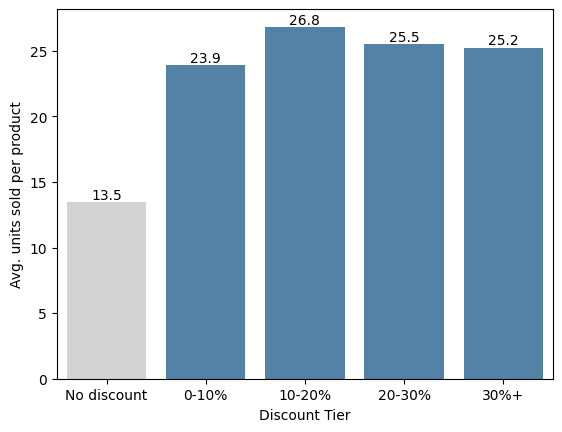

In [11]:
# Plot average units sold by discount bucket, with the no-discount bar in gray.
# Roll the data up to one row per product: its average discount, total revenue, total units, and how many times it sold.
by_sku = disc.groupby('sku').agg(
    avg_dis_pct=('discount_pct', 'mean'),
    total_revenue=('revenue', 'sum'),
    total_units=('product_quantity', 'sum'),
    n_lines=('id_order', 'count')
    ).reset_index()

by_sku

# Keep only products that sold at least 5 times, so the averages are reliable.
by_sku_5 = by_sku[by_sku['n_lines'] >= 5]
by_sku_5
# Sort each product into a discount bucket: no discount, 0-10%, 10-20%, 20-30%, or 30%+.
by_sku_5['tier'] = 'No discount'
by_sku_5.loc[(by_sku_5['avg_dis_pct'] > 0) & (by_sku_5['avg_dis_pct'] <= 10), 'tier'] = '0-10%'
by_sku_5.loc[(by_sku_5['avg_dis_pct'] > 10) & (by_sku_5['avg_dis_pct'] <= 20), 'tier'] = '10-20%'
by_sku_5.loc[(by_sku_5['avg_dis_pct'] > 20) & (by_sku_5['avg_dis_pct'] <= 30), 'tier'] = '20-30%'
by_sku_5.loc[by_sku_5['avg_dis_pct'] > 30, 'tier'] = '30%+'

# Check the result.
by_sku_5

# Set the order we want these buckets to appear in.
tier_order = ['No discount', '0-10%', '10-20%', '20-30%', '30%+']

# Find the average units sold and average revenue for each discount bucket.
tier_avg = by_sku_5.groupby('tier').agg(mean_units = ('total_units', 'mean'), mean_revenue = ('total_revenue', 'mean'))
tier_avg = tier_avg.reindex(tier_order)
tier_avg = tier_avg.reset_index()
tier_avg
ax = sns.barplot(data=tier_avg, x='tier', y='mean_units', color='steelblue')
ax.set_ylabel('Avg. units sold per product')
ax.set_xlabel('Discount Tier')
ax.bar_label(ax.containers[0], fmt='%.1f')
ax.patches[0].set_facecolor('lightgray')

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

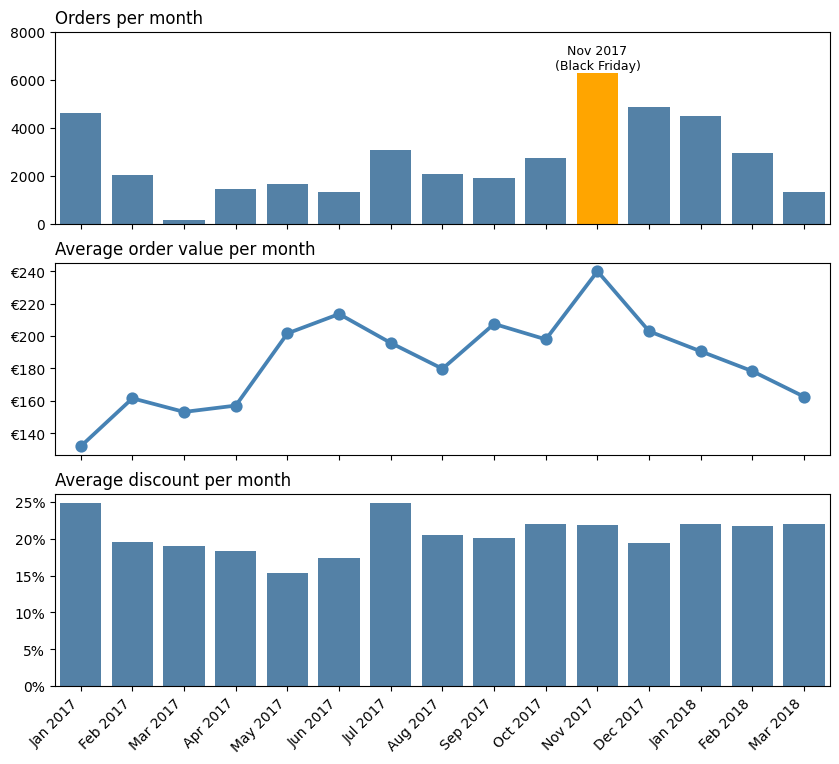

In [12]:
# Plot three things together: orders per month, average order value, and average discount -- with November 2017 (Black Friday) flagged.
# Collapse the data to one row per order, with total revenue and order date.
grp_by_orders = disc.groupby('id_order').agg(order_revenue=('revenue', 'sum'), order_date=('date', 'min')).reset_index()
grp_by_orders
# Pull out the month from each order's date.
grp_by_orders['month'] = grp_by_orders['order_date'].dt.to_period('M')
grp_by_orders
# Count orders and find the average order value for each month.
monthly = grp_by_orders.groupby('month').agg(
    n_orders=('id_order', 'nunique'),
    avg_order_value=('order_revenue', 'mean'))
monthly
# Add that same month column to the full line-level data.
disc['month'] = disc['date'].dt.to_period('M')
disc

# Add the average discount for each month too.
monthly['avg_discount_pct'] = disc.groupby('month')['discount_pct'].mean()
# Turn the month index back into a normal column.
monthly.reset_index(inplace=True)
monthly

# Make a readable month label like 'Jan 2017' for the chart.
monthly['month_label'] = monthly.month.dt.strftime('%b %Y')
monthly

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8.5), sharex=True)
#first plot
sns.barplot(data=monthly, x='month_label', y='n_orders', color='steelblue', ax=ax1)
ax1.set_title('Orders per month',loc='left')
ax1.set_xlabel('')
ax1.set_ylabel('')

peak_i = monthly['n_orders'].idxmax()
ax1.patches[peak_i].set_facecolor('orange')
ax1.text(peak_i, monthly['n_orders'].max() + 150, 'Nov 2017\n(Black Friday)', ha='center', fontsize=9)
ax1.set_ylim(0, 8000)

#second plot
sns.pointplot(data=monthly, x='month_label', y='avg_order_value', color='steelblue'
, ax=ax2)
ax2.set_title('Average order value per month', loc='left')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.yaxis.set_major_formatter(lambda v, pos: f'€{v:,.0f}')

#third plot
sns.barplot(data=monthly, x='month_label', y='avg_discount_pct', color='steelblue', ax=ax3)
ax3.set_title('Average discount per month', loc='left')
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.yaxis.set_major_formatter(lambda v, pos: f'{v:.0f}%')


plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

**Order Volume and total revenue per category**

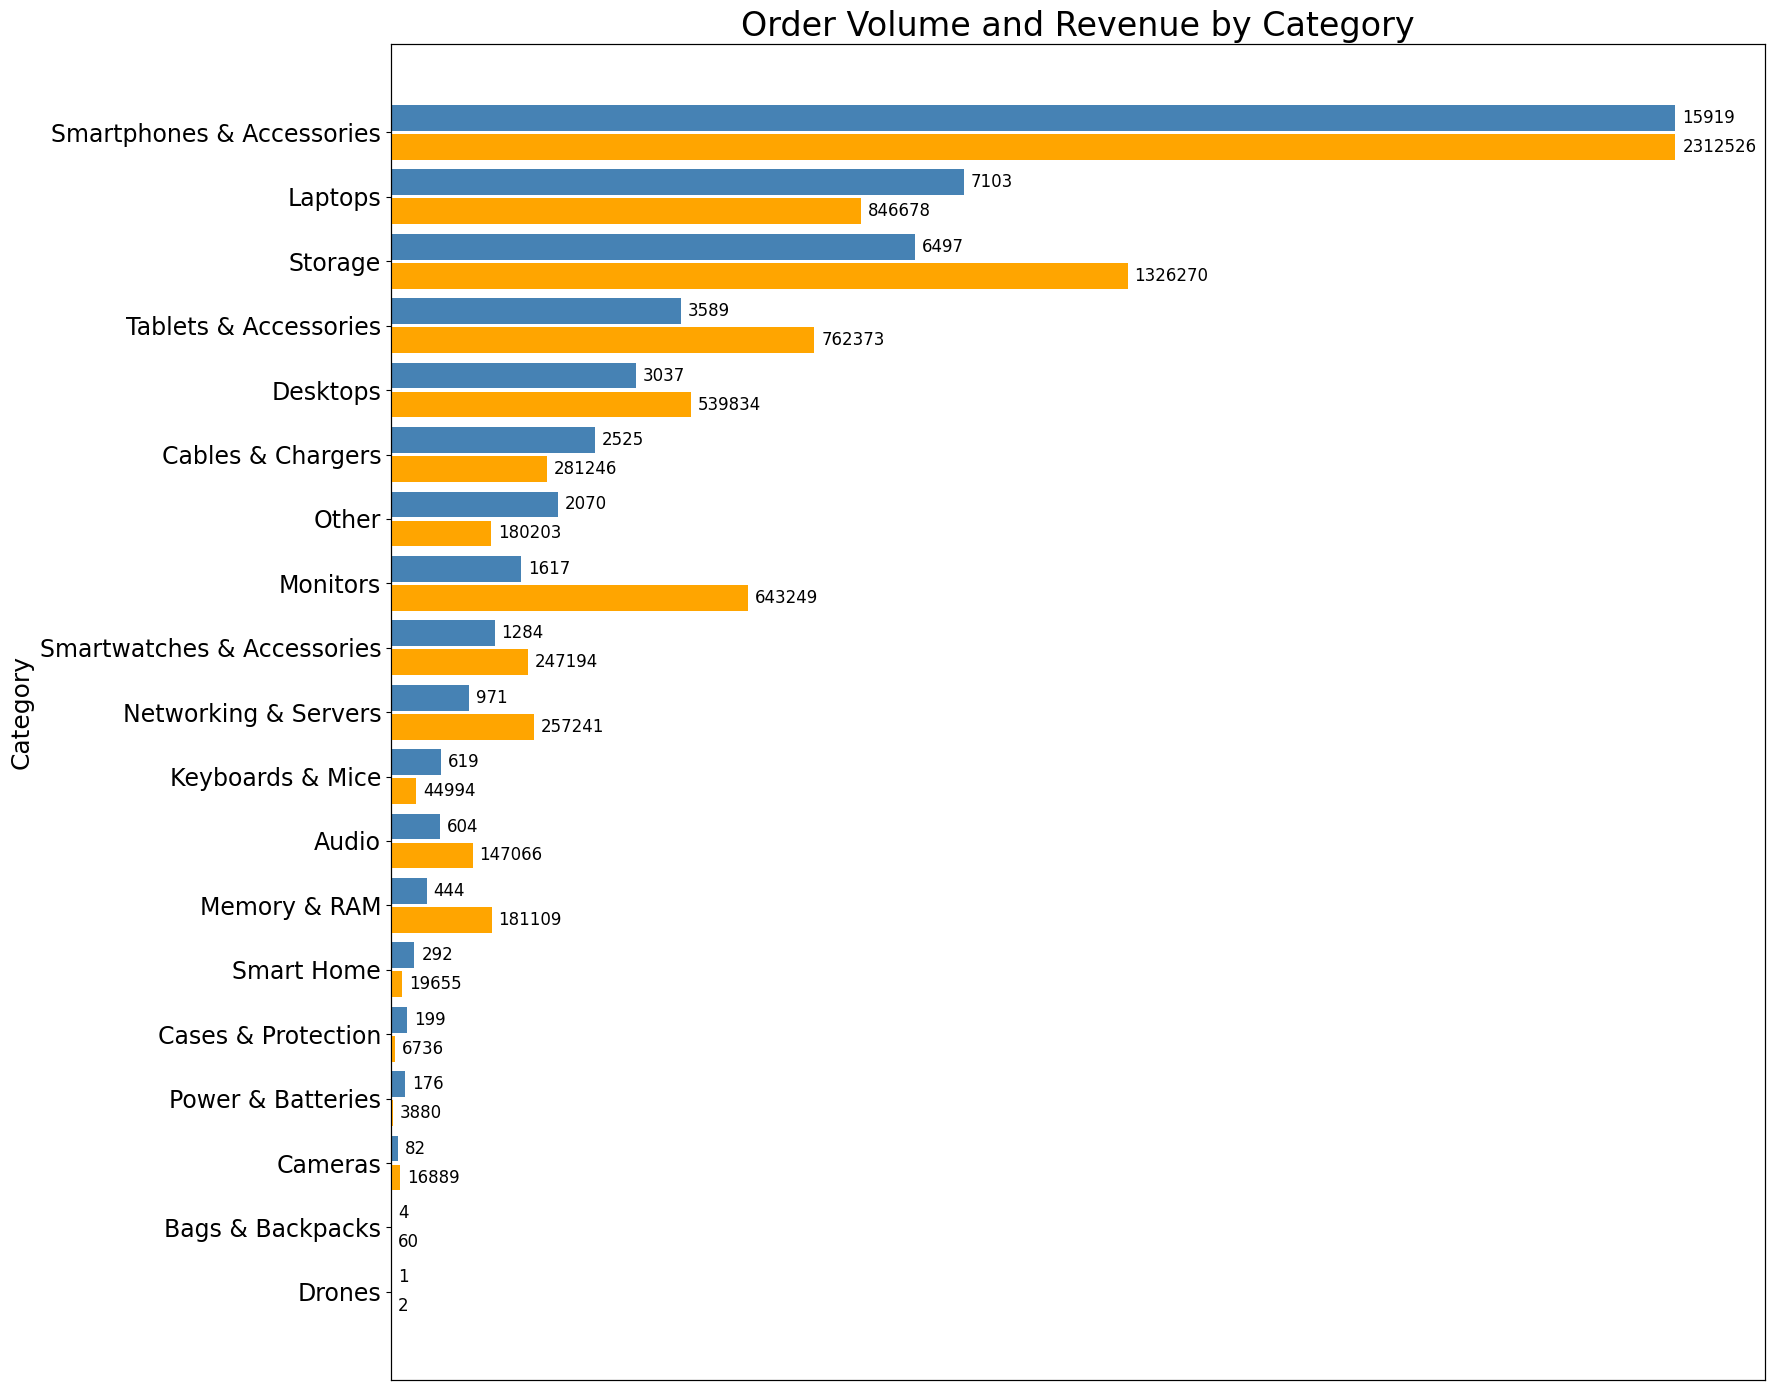

In [13]:
# Order Volume and Revenue by Category
# Calculate order volume and revenue by category
category_performance = (
    Final_df
    .groupby('category')
    .agg(
        order_volume=('id_order', 'nunique'),
        revenue=('unit_price_total', 'sum'))
    .reset_index())
# Sort by order volume
category_performance = category_performance.sort_values(
    'order_volume',
    ascending=True)
# Define positions with more space between categories
y_positions = range(0, len(category_performance) * 2, 2)
# Create the plot
fig, ax1 = plt.subplots(figsize=(18, 14))
# Order Volume
ax1.barh(
    [y + 0.45 for y in y_positions],
    category_performance['order_volume'],
    height=0.8,
    color='steelblue',
    label='Order Volume')
# Create a second x-axis for Revenue
ax2 = ax1.twiny()
# Revenue
ax2.barh(
    [y - 0.45 for y in y_positions],
    category_performance['revenue'],
    height=0.8,
    color='orange',
    label='Revenue')
# Set category labels between the two bars
ax1.set_yticks(y_positions)
ax1.set_yticklabels(
    category_performance['category'],
    fontsize=17)
# Remove x-axis labels and tick values
ax1.set_xlabel('')
ax2.set_xlabel('')
ax1.tick_params(
    axis='x',
    labelbottom=False,
    bottom=False)
ax2.tick_params(
    axis='x',
    labeltop=False,
    top=False)
# Keep category axis title
ax1.set_ylabel(
    'Category',
    fontsize=18)
# Increase category label size
ax1.tick_params(
    axis='y',
    labelsize=17)
# Add values to Order Volume bars
ax1.bar_label(
    ax1.containers[0],
    fmt='%.0f',
    padding=5,
    fontsize=12)
# Add values to Revenue bars
ax2.bar_label(
    ax2.containers[0],
    fmt='%.0f',
    padding=5,
    fontsize=12)
# Set title
plt.title(
    'Order Volume and Revenue by Category',
    fontsize=24)
# Adjust layout
plt.tight_layout()
ax1.set_xlim(
    right=category_performance['order_volume'].max() * 1.07)
ax2.set_xlim(
    right=category_performance['revenue'].max() * 1.07)
# Show plot
plt.show()

**Revenue per Order: Top performer**

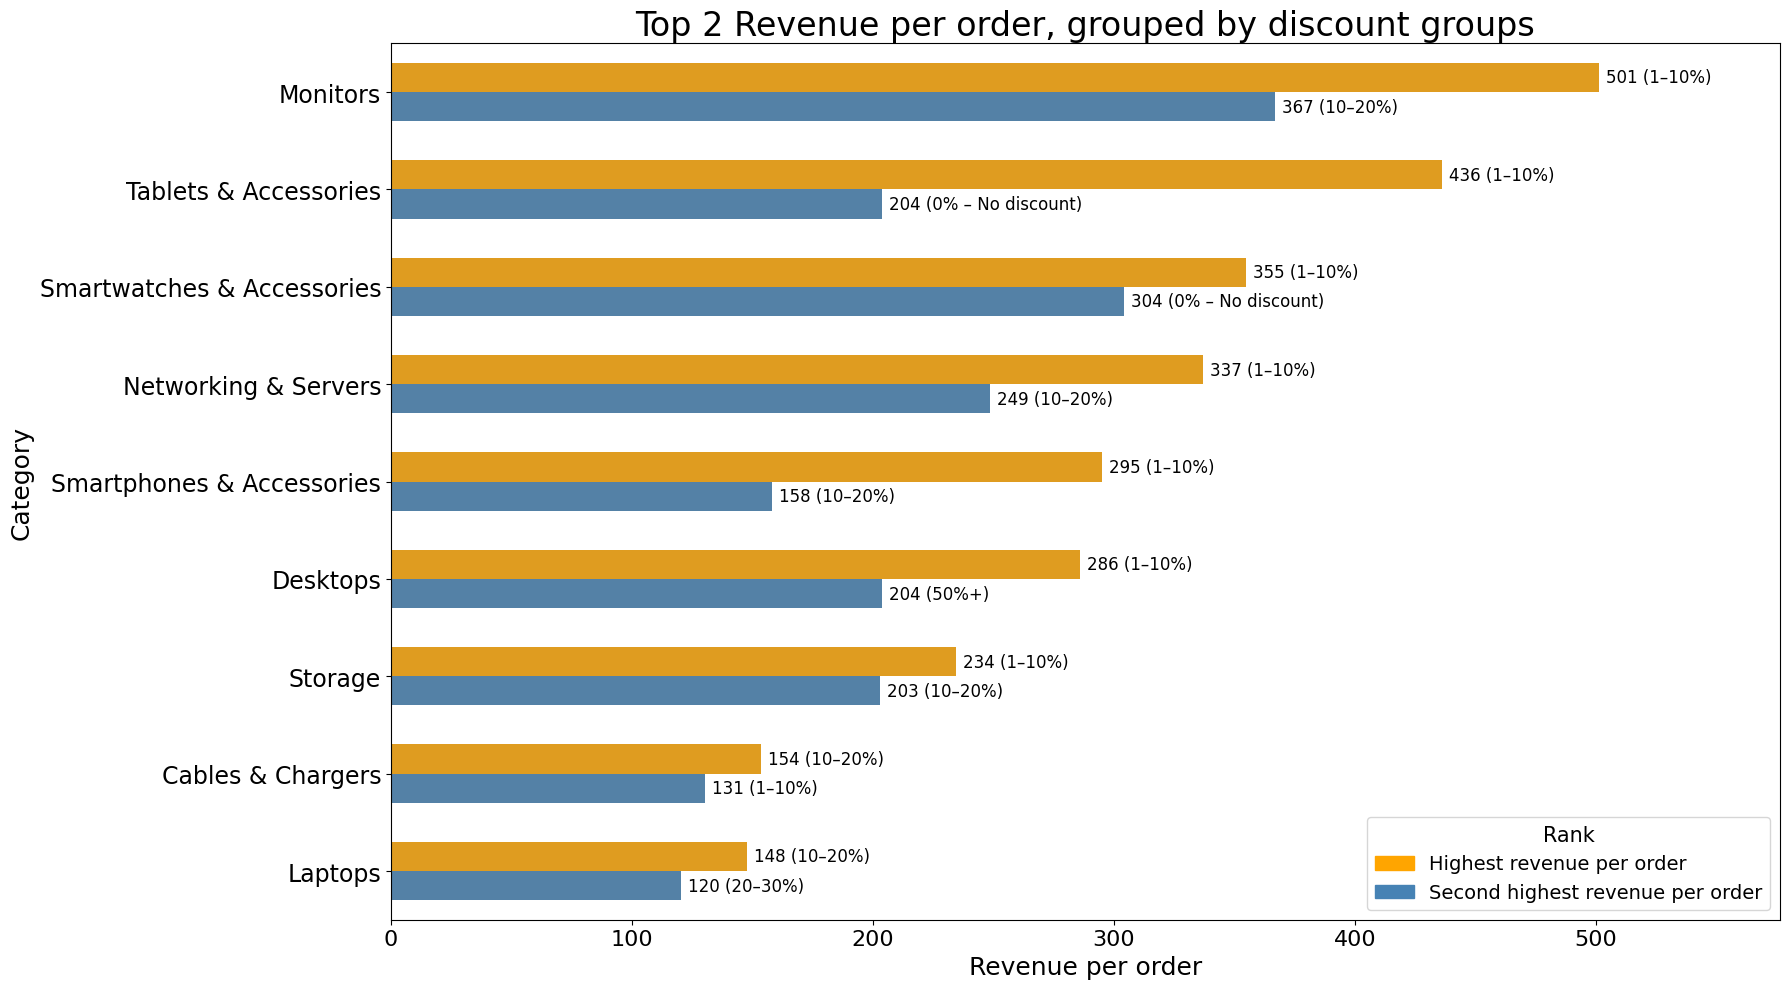

In [14]:
# Top 9 Categories by Revenue
# Calculate revenue by category
revenue_by_category = (
    Final_df
    .groupby('category')
    .agg(
        revenue=('unit_price_total', 'sum'))
    .reset_index()
    .sort_values('revenue', ascending=False))

# Select the 9 categories with the highest revenue
top_9_categories = revenue_by_category.head(9)
# Store the category names for the following analysis
selected_categories = top_9_categories['category'].tolist()
# Top 2 Revenue per Order by Category
# Create the analysis dataset
KPI_df = Final_df[
    Final_df['category'].isin(selected_categories)
].copy()
# Create discount groups
KPI_df['discount_group'] = pd.cut(
    KPI_df['discount_percent'],
    bins=[-0.01, 0, 10, 20, 30, 40, 50, 100],
    labels=[
        '0% – No discount',
        '1–10%',
        '10–20%',
        '20–30%',
        '30–40%',
        '40–50%',
        '50%+'],
    include_lowest=True)
# Calculate sales performance by category and discount group
performance_summary = (
    KPI_df
    .groupby(
        ['category', 'discount_group'],
        observed=True)
    .agg(
        orders=('id_order', 'nunique'),
        product_quantity=('product_quantity', 'sum'),
        total_revenue=('unit_price_total', 'sum'))
    .reset_index())
# Calculate revenue per order
performance_summary['revenue_per_order'] = (
    performance_summary['total_revenue']
    / performance_summary['orders'])
# Calculate revenue per product
performance_summary['revenue_per_product'] = (
    performance_summary['total_revenue']
    / performance_summary['product_quantity'])
# Rank discount groups by revenue per order within each category
performance_summary['revenue_rank'] = (
    performance_summary
    .groupby('category')['revenue_per_order']
    .rank(method='first', ascending=False))
# Keep only the two highest revenue per order groups
best_two_discount = (
    performance_summary[
        performance_summary['revenue_rank'] <= 2].copy())
# Sort categories by the highest revenue per order
category_order = (
    best_two_discount
    .groupby('category')['revenue_per_order']
    .max()
    .sort_values(ascending=False)
    .index)
best_two_discount['category'] = pd.Categorical(
    best_two_discount['category'],
    categories=category_order,
    ordered=True)
# Create the plot
fig, ax = plt.subplots(figsize=(18, 10))
sns.barplot(
    data=best_two_discount,
    x='revenue_per_order',
    y='category',
    hue='revenue_rank',
    hue_order=[1, 2],
    palette={
        1: 'orange',
        2: 'steelblue'},
    dodge=True,
    width=0.6,
    ax=ax)
# Prepare data for the labels
rank_1 = best_two_discount[
    best_two_discount['revenue_rank'] == 1
].sort_values('category')

rank_2 = best_two_discount[
    best_two_discount['revenue_rank'] == 2
].sort_values('category')
# Add values and discount groups to the bars
ax.bar_label(
    ax.containers[0],
    labels=[
        f"{value:.0f} ({group})"
        for value, group in zip(
            rank_1['revenue_per_order'],
            rank_1['discount_group'])],
    padding=5,
    fontsize=12)
ax.bar_label(
    ax.containers[1],
    labels=[
        f"{value:.0f} ({group})"
        for value, group in zip(
            rank_2['revenue_per_order'],
            rank_2['discount_group'])],
    padding=5,
    fontsize=12)
# Add space for the labels on the right
ax.set_xlim(
    right=best_two_discount['revenue_per_order'].max() * 1.15)
# Set axis labels
ax.set_xlabel(
    'Revenue per order',
    fontsize=18)
ax.set_ylabel(
    'Category',
    fontsize=18)
# Set title
ax.set_title(
    'Top 2 Revenue per order, grouped by discount groups',
    fontsize=24)
# Increase tick label size
ax.tick_params(
    axis='x',
    labelsize=16)
ax.tick_params(
    axis='y',
    labelsize=17)
# Create custom legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='orange', label='Highest revenue per order'),
    Patch(color='steelblue', label='Second highest revenue per order')]
ax.legend(
    handles=legend_handles,
    title='Rank',
    fontsize=14,
    title_fontsize=15)
# Adjust layout
plt.tight_layout()
# Show plot
plt.show()